# Imports

In [60]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import axes


# Load data

In [62]:
games_odds = pd.read_csv("data/game_odds.csv")
games_index = pd.read_csv("data/games_index.csv")
games_schedule = pd.read_csv("data/games_schedule.csv")
play_by_play = pd.read_csv("data/play_by_play.csv")
player_boxscores = pd.read_csv("data/player_boxscores.csv")
team_boxscores = pd.read_csv("data/team_boxscores.csv")

In [ ]:
# print("Game Odds:")
# display(games_odds.head())
# print("Games Index:")
# display(games_index.head())
# print("Games Schedule:")
# display(games_schedule.head())
# print("Play-by-Play:")
# display(play_by_play.head())
# print("Player Boxscores:")
# display(player_boxscores.head())
# print("Team Boxscores:")
# display(team_boxscores.head())


Aggregated Player Stats:


,player_id,player_name,team_abbreviation,games,points,rebounds,assists,steals,blocks,turnovers,minutes,Field Goals Made,Field Goals Attempted,Three Pointers Made,Three Pointers Attempted,Free Throws Made,Free Throws Attempted,impact of player on team performance,defensive rebounds,offensive rebounds
0,2,Byron Scott,LAL,87,6.632184,1.494253,1.264368,0.540230,0.183908,0.701149,18.082701,2.045977,4.735632,0.885057,2.287356,1.655172,1.954023,3.080460,1.252874,0.241379
1,3,Grant Long,ATL,59,10.067797,6.271186,1.033898,1.271186,0.338983,1.644068,29.463927,3.169492,7.576271,0.067797,0.372881,3.661017,4.728814,3.288136,4.101695,2.169492
2,3,Grant Long,BOS,49,1.510204,1.795918,0.530612,0.183673,0.020408,0.408163,10.700510,0.571429,1.510204,0.000000,0.061224,0.367347,0.469388,-1.693878,1.244898,0.551020
3,3,Grant Long,DET,110,4.472727,3.481818,0.609091,0.690909,0.163636,0.636364,18.175136,1.645455,3.727273,0.154545,0.481818,1.027273,1.381818,0.700000,2.127273,1.354545
4,3,Grant Long,MEM,66,6.318182,3.500000,2.060606,0.954545,0.181818,1.560606,28.304571,2.484848,5.833333,0.045455,0.257576,1.303030,1.863636,-5.818182,3.030303,0.469697
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8343,1643133,Lawson Lovering,MEM,2,7.000000,7.500000,1.500000,1.500000,0.500000,1.000000,24.632500,3.000000,5.000000,0.000000,0.000000,1.000000,2.500000,0.500000,4.500000,3.000000
8344,1643141,Jahmyl Telfort,LAC,8,0.125000,0.375000,0.125000,0.125000,0.000000,0.125000,4.004167,0.000000,0.500000,0.000000,0.500000,0.125000,0.500000,-0.875000,0.375000,0.000000
8345,1643158,Andersson Garcia,UTA,5,5.200000,8.400000,2.800000,1.600000,0.800000,1.400000,33.750000,1.800000,5.800000,0.200000,2.600000,1.400000,1.800000,-7.400000,5.000000,3.400000
8346,1643253,Toby Okani,MEM,6,10.000000,3.500000,1.000000,0.666667,0.500000,0.500000,36.181667,4.166667,11.666667,1.500000,5.166667,0.166667,1.333333,-22.833333,2.000000,1.500000


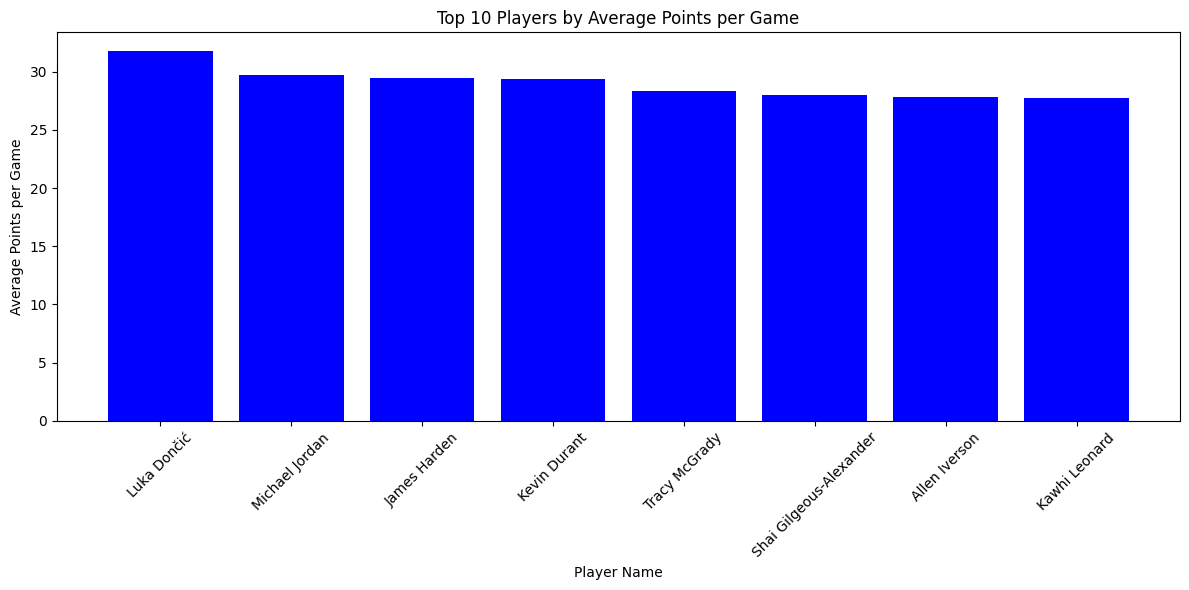

                  player_name     points
7031              Luka Dončić  31.783505
1049           Michael Jordan  29.696078
4507             James Harden  29.434844
3996             Kevin Durant  29.349315
7030              Luka Dončić  28.887712
3999             Kevin Durant  28.469325
1561            Tracy McGrady  28.316129
6911  Shai Gilgeous-Alexander  27.965587
1174            Allen Iverson  27.844388
5110            Kawhi Leonard  27.714286


In [ ]:
stat_columns = {
        "pts":   "points",
        "reb":   "rebounds",
        "ast":   "assists",
        "stl":   "steals",
        "blk":   "blocks",
        "tov":   "turnovers",
        "min":   "minutes",
        "fgm":   "Field Goals Made",
        "fga":   "Field Goals Attempted",
        "fg3m":  "Three Pointers Made",
        "fg3a":  "Three Pointers Attempted",
        "ftm":   "Free Throws Made",
        "fta":   "Free Throws Attempted",
        "plus_minus": "impact of player on team performance",
        "dreb":  "defensive rebounds",
        "oreb":  "offensive rebounds",
    }
available = {k: v for k, v in stat_columns.items() if k in player_boxscores.columns}
agg_summary = (
        player_boxscores.groupby(["player_id", "player_name", "team_abbreviation"], as_index=False)
          .agg(
              games=("game_id", "nunique"),
              **{v: (k, "mean") for k, v in available.items()}
          )
    )
print("Aggregated Player Stats:")
display(agg_summary)

# Example: Plotting average points per game for top 10 players
top_players = agg_summary.sort_values("points", ascending=False).head(10)
plt.figure(figsize=(12, 6))
plt.bar(top_players["player_name"], top_players["points"], color='blue')
plt.xlabel("Player Name")
plt.ylabel("Average Points per Game")
plt.title("Top 10 Players by Average Points per Game")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(top_players[["player_name", "points"]])

In [ ]:
#teams aggregate stats from team boxscores
team_agg_summary = (
        team_boxscores.groupby(["team_id", "team_abbreviation"], as_index=False)
            .agg(
                games=("game_id", "nunique"),
                **{v: (k, "mean") for k, v in available.items()}
            )
    )
print("Aggregated Team Stats:")
display(team_agg_summary)

Aggregated Team Stats:


,team_id,team_abbreviation,games,points,rebounds,assists,steals,blocks,turnovers,minutes,Field Goals Made,Field Goals Attempted,Three Pointers Made,Three Pointers Attempted,Free Throws Made,Free Throws Attempted,impact of player on team performance,defensive rebounds,offensive rebounds
0,1610612737,ATL,2543,101.464412,42.364137,22.457334,7.717656,4.863154,14.768777,48.345864,37.663390,83.120330,8.164766,23.022414,17.972867,23.451042,-1.289422,31.218246,11.145891
1,1610612738,BOS,2687,102.586528,42.285076,22.852252,8.126907,4.704503,14.416822,48.368310,37.764049,83.082620,9.148121,25.432453,17.910309,23.205806,2.289542,31.708597,10.576479
2,1610612739,CLE,2576,100.987966,42.607531,22.385870,7.440606,4.569099,14.503106,48.331727,37.408385,82.289596,8.133152,22.564441,18.038043,24.048137,0.013975,31.322593,11.284938
3,1610612740,NOH,758,94.298153,41.176781,21.022427,7.455145,4.324538,13.894459,48.349602,35.687335,80.104222,6.002639,16.934037,16.920844,21.956464,-0.927441,29.687335,11.489446
4,1610612740,NOK,164,94.170732,41.670732,18.634146,6.908537,4.012195,13.914634,48.396341,35.378049,79.890244,4.603659,13.054878,18.810976,25.103659,-2.195122,29.823171,11.847561
5,1610612740,NOP,1074,109.621974,44.399441,24.842644,7.908752,5.078212,14.179702,48.325858,40.886406,87.810056,10.154562,28.510242,17.694600,23.139665,-1.453445,33.569832,10.829609
6,1610612741,CHI,2526,99.859857,43.528899,22.950515,7.504751,4.841251,14.711006,48.401122,37.539192,83.789786,7.438242,20.887965,17.343230,22.831750,-1.055819,31.994458,11.534442
7,1610612742,DAL,2598,103.717090,42.260200,21.995766,7.276366,4.829484,13.178599,48.330681,38.370670,83.811008,8.908006,24.671286,18.067744,23.123172,1.282140,31.712471,10.547729
8,1610612743,DEN,2557,104.988268,43.429018,24.176770,7.789597,5.210012,14.696910,48.322566,38.956590,84.488854,8.099726,22.717638,18.975362,25.076261,0.279625,31.821666,11.607352
9,1610612744,GSW,2573,105.994948,43.900894,24.632724,8.212981,5.188496,15.052079,48.297194,39.415080,86.206374,9.501749,25.845705,17.663039,23.275165,0.420132,32.104547,11.796347


Team Wins:


winner
SAS    1661
LAL    1533
MIA    1519
BOS    1490
DAL    1419
HOU    1380
UTA    1379
IND    1375
PHX    1338
DEN    1317
CLE    1308
GSW    1296
POR    1294
MIL    1266
DET    1231
PHI    1216
LAC    1213
TOR    1211
CHI    1209
ATL    1193
ORL    1173
NYK    1167
MIN    1138
SAC    1117
MEM    1011
WAS    1004
OKC     941
CHA     699
NJN     591
SEA     512
BKN     511
NOP     469
NOH     357
CHH     285
VAN      86
NOK      77
Name: count, dtype: int64

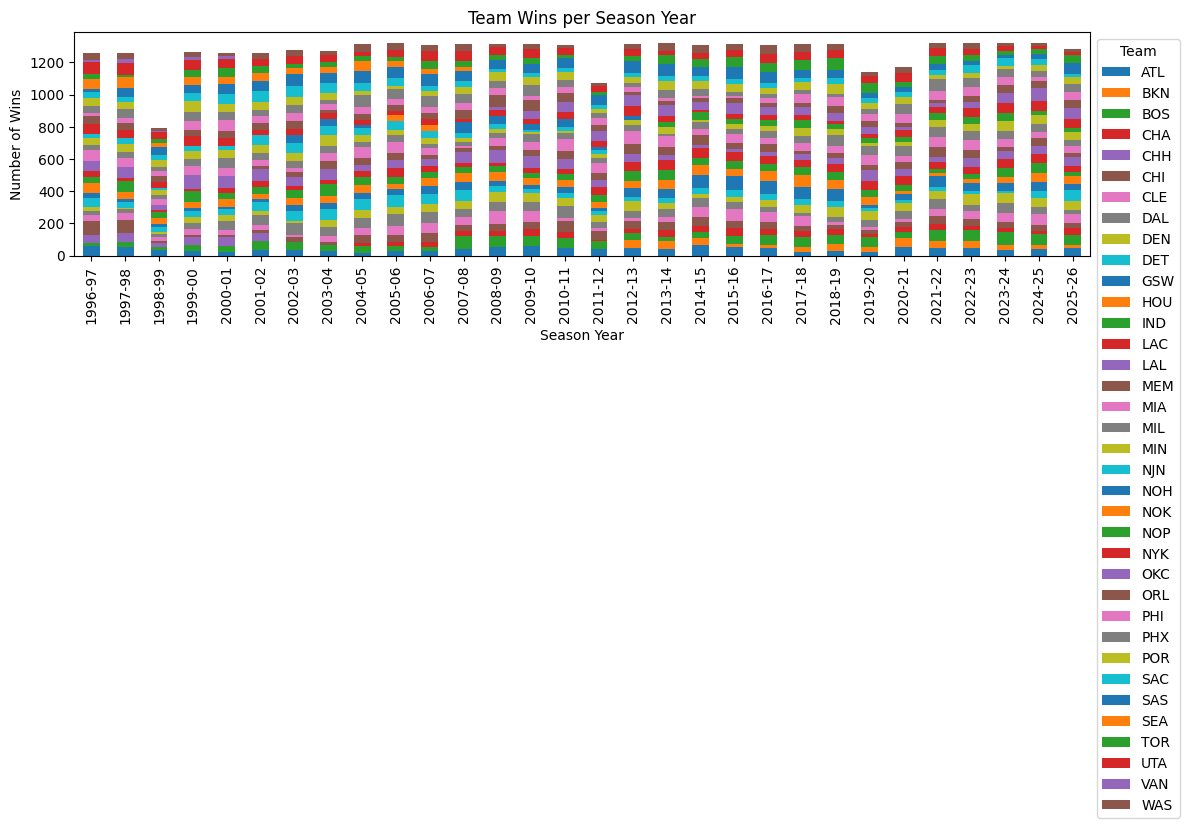

In [ ]:
teams_dict = {
    "ATL": "Atlanta Hawks",
    "BOS": "Boston Celtics",
    "BKN": "Brooklyn Nets",
    "CHA": "Charlotte Hornets",
    "CHI": "Chicago Bulls",
    "CLE": "Cleveland Cavaliers",
    "DAL": "Dallas Mavericks",
    "DEN": "Denver Nuggets",
    "DET": "Detroit Pistons",
    "GSW": "Golden State Warriors",
    "HOU": "Houston Rockets",
    "IND": "Indiana Pacers",
    "LAC": "Los Angeles Clippers",
    "LAL": "Los Angeles Lakers",
    "MEM": "Memphis Grizzlies",
    "MIA": "Miami Heat",
    "MIL": "Milwaukee Bucks",
    "MIN": "Minnesota Timberwolves",
    "NOP": "New Orleans Pelicans",
    "NYK": "New York Knicks",
    "OKC": "Oklahoma City Thunder",
    "ORL": "Orlando Magic",
    "PHI": "Philadelphia 76ers",
    "PHX": "Phoenix Suns",
    "POR": "Portland Trail Blazers",
    "SAC": "Sacramento Kings",
    "SAS": "San Antonio Spurs",
    "TOR": "Toronto Raptors",
    "UTA": "Utah Jazz",
    "WAS": "Washington Wizards"
}

# get all the wins for each team from games_index 
team_wins = games_index["winner"].value_counts()
print("Team Wins:")
display(team_wins)

# bar plot of team wins per season year
team_wins_per_year = games_index.groupby(["season_year", "winner"]).size().unstack(fill_value=0)
team_wins_per_year.plot(kind="bar", stacked=True, figsize=(12, 6))
plt.xlabel("Season Year")
plt.ylabel("Number of Wins")
plt.title("Team Wins per Season Year")
plt.legend(title="Team", bbox_to_anchor=(1, 1), loc='upper left')
plt.tight_layout()
plt.show()

Luka Dončić has played for the following teams: DAL, LAL


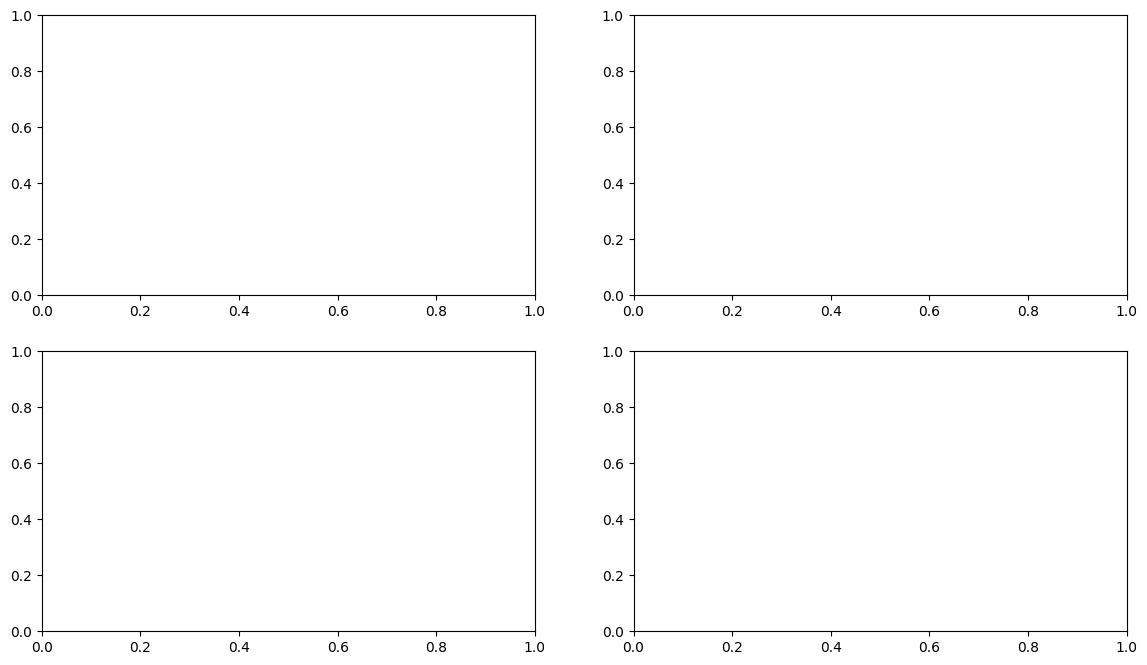

In [63]:
# Teams for Luka Doncic
luka_teams = agg_summary[agg_summary["player_name"] == "Luka Dončić"]["team_abbreviation"].unique()
print(f"Luka Dončić has played for the following teams: {', '.join(luka_teams)}")

# plot DAL stats before and after Luka's arrival, and beforw and after he leaves
fig = plt.subplots(2,2,figsize=(14, 8))


